# Notebook 10 — Segmentación de instancia end-to-end con Mask2Former

## Idea

Sucesor del pipeline detect-then-segment de `plan/detection-segmentation-guide.md`
(YOLO + SAM3, notebooks 08–09), cuyo fallo medido se documenta en
`plan/notebooks-08-09-closeout.md`: SAM3 congelado encuentra los píxeles de una traza
aislada (`frac_own` 0.94–0.96) pero asigna identidad al azar en cruces (`frac_own` ≈
0.5), en las tres variantes de prompting probadas. Un `Mask2FormerForUniversalSegmentation`
reemplaza las dos etapas con un solo modelo afinable: _queries_ aprendidas que compiten
por píxel (en vez de un prompt externo por caja) y cuya identidad se supervisa por
matching húngaro contra el ground truth de `synthkymo` — cada cruce sintético (GT
resuelve todos exactamente, por `particle_id`) es un ejemplo de entrenamiento de "la
identidad continúa a través del cruce". Guía completa: `plan/mask2former-guide.md`.

**Alcance de este notebook** (ver sección 8 para el detalle honesto de qué corrió acá
y qué no): implementa y valida de punta a punta los pasos 1–4 del checklist de la guía
—verificación de imports, capa de exportación de datos, chequeo visual, y un
_smoke-test_ de fine-tuning en MPS que confirma que la pérdida baja—. El fine-tuning
completo (cloud/cluster, WBS 5.2/6.2) y las cifras finales de la tabla comparativa
(pasos 5–9) requieren presupuesto de cómputo que no es de este notebook gastar; quedan
como una celda con bandera explícita (`EJECUTAR_FINE_TUNE_COMPLETO`), documentada pero
sin ejecutar.


## 0. Setup


In [16]:
import os

# Mask2Former usa grid_sample en el muestreo de puntos de su perdida (point-based mask
# loss); `grid_sampler_2d_backward` todavia no esta implementado para MPS
# (NotImplementedError al correr el smoke-test sin esta variable). El fallback a CPU
# para ESE operador puntual es aceptable -- el resto del forward/backward sigue en MPS.
# OJO: PyTorch lee esta variable AL IMPORTAR torch, asi que tiene que setearse ANTES
# del `import torch` -- si torch ya se importo en este kernel sin la variable, hay que
# reiniciar el kernel y correr esta celda primero.
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import sys
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import torch

sys.path.append(str(Path("..") / "src"))
from axonal_tracking import etiquetas_deteccion as ed
from axonal_tracking import evaluacion as ev

RAIZ = Path("..").resolve()
DATASETS = RAIZ / "datasets"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

Device: mps


## 1. Verificar imports + cargar checkpoint (checklist paso 1)

`transformers>=4.57` ya es dependencia del proyecto (provee `Sam3Model`); confirmar acá
que la instalación concreta expone `Mask2FormerForUniversalSegmentation` +
`Mask2FormerImageProcessor` **antes** de escribir el resto del notebook — misma
disciplina de "chequear contra la librería instalada" que en el Paso 4.0 de la guía
anterior detectó que `Sam3Model` no aceptaba point-prompts.

También se confirma que `EomtForUniversalSegmentation`/`EomtImageProcessor` importan
(el sucesor CVPR 2025 que la guía §1 deja como fila opcional) — sin usarlo todavía: la
guía lo condiciona a que la fila de Mask2Former ya exista.


In [17]:
from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor

try:
    from transformers import (
        EomtForUniversalSegmentation,
        EomtImageProcessor,
    )  # noqa: F401

    print(
        "EomtForUniversalSegmentation / EomtImageProcessor: OK (fila opcional, no usada aun)"
    )
except ImportError as e:
    print(f"Eomt no disponible en esta instalacion de transformers: {e}")

import transformers

print(f"transformers {transformers.__version__}")

MODEL_ID = "facebook/mask2former-swin-tiny-coco-instance"
CLASE_MOVIL, CLASE_ESTATICO = ed.CLASE_MOVIL, ed.CLASE_ESTATICO

# id2label/label2id explicitos (2 clases: movil + estatico, decision SS2 de la guia)
# en vez de solo num_labels: ademas de redimensionar la cabeza de clases, deja el mapa
# de clases correcto en el config -- sin esto, el checkpoint guardado por SS5.2
# arrastraria el id2label de las 80 clases de COCO (confuso al recargarlo despues).
ID2LABEL = dict(enumerate(ed.CLASES))
processor = Mask2FormerImageProcessor.from_pretrained(MODEL_ID)
modelo = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_ID,
    id2label=ID2LABEL,
    label2id={v: k for k, v in ID2LABEL.items()},
    ignore_mismatched_sizes=True,
).to(device)

n_params = sum(p.numel() for p in modelo.parameters()) / 1e6
print(
    f"\n{MODEL_ID} cargado: {n_params:.1f}M parametros, num_queries={modelo.config.num_queries}"
)
print(
    f"clases: {modelo.config.id2label} (+ 1 clase interna 'no-object' que Mask2Former agrega siempre)"
)

EomtForUniversalSegmentation / EomtImageProcessor: OK (fila opcional, no usada aun)
transformers 5.9.0


Loading weights:   0%|          | 0/554 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                                                                                                                                | Status     |                                                                                        
-----------------------------------------------------------------------------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0, 1, 2, 3, 4, 5}.attention.self.relative_position_index | UNEXPECTED |                                                                                        
model.pixel_level_module.encoder.swin.layernorm.bias                                                                               | MISSING    |                                       


facebook/mask2former-swin-tiny-coco-instance cargado: 47.4M parametros, num_queries=100
clases: {0: 'movil', 1: 'estatico'} (+ 1 clase interna 'no-object' que Mask2Former agrega siempre)


## 2. Datos: instancias por muestra (checklist paso 2)

**Decisión de clases** (mirror de la pregunta de dos clases de NB08, misma decisión
tomada de forma deliberada): **dos clases, `movil` + `estatico`**, igual que
`etiquetas_deteccion.CLASES`. Motivo (guía §2): las bandas estáticas verticales son
justo donde las máscaras de SAM3 se filtraban (NB09 §9, `leakage`); darle al modelo un
slot de query que _reclame_ esos píxeles como `estatico` le da una salida explícita en
vez de dejarlo confundir estático con móvil. Si las queries de `estatico` salen
ruidosas (misma señal que vigiló NB08), la re-corrida movers-only es un cambio de un
parámetro (`etiquetar_estaticos=False`), mismos datos.

**Splits**: los mismos `datasets/{train,val,test}/sample_*` disjuntos por `base_seed`
que usan NB08/09 — mismo split de test (400 muestras) para que cualquier número sea
directamente comparable.

**`min_desplazamiento_px = 8.0`, no 1.0**: `ed.MIN_DESPLAZAMIENTO_PX_MOVIL` (ver su
docstring) — es el umbral que aprendió el YOLO evaluado en NB09. Si esta exportación
usara el default de `cajas_desde_positions` (1.0), el subconjunto "móvil"/"ambiguo" de
este notebook mediría una definición distinta y dejaría de ser comparable a las filas
A_box/B_point/C_seq.


In [18]:
MIN_DESPLAZAMIENTO_PX = ed.MIN_DESPLAZAMIENTO_PX_MOVIL  # 8.0, ver docstring
print(f"MIN_DESPLAZAMIENTO_PX = {MIN_DESPLAZAMIENTO_PX}")


def cargar_escena(sample_dir: Path) -> dict:
    """Lee una muestra de synthkymo cruda (sin pasar por yolo_detection/): kymografo
    2D, positions.csv completo, y los escalares de su config.yaml."""
    positions = pd.read_csv(sample_dir / "positions.csv")
    cfg = yaml.safe_load((sample_dir / "config.yaml").read_text())
    kymo = ed._leer_kymografo_tif(sample_dir / "kymograph.tif")
    if kymo.ndim == 3:
        kymo = kymo[..., 0]
    return {
        "nombre": sample_dir.name,
        "kymo": kymo,
        "positions": positions,
        "pixel_scale_um": float(cfg["general"]["pixel_scale_um"]),
        "fps": float(cfg["general"]["fps"]),
    }


# demo sobre una muestra con cruce (dos moviles con columnas superpuestas), la misma
# usada en la verificacion de SS2.1 de abajo
escena_demo = cargar_escena(DATASETS / "test" / "sample_00016")
T, L = escena_demo["kymo"].shape
instancias_demo = ed.instancias_desde_positions(
    escena_demo["positions"],
    escena_demo["pixel_scale_um"],
    (T, L),
    min_desplazamiento_px=MIN_DESPLAZAMIENTO_PX,
)
n_movil = sum(i.clase == CLASE_MOVIL for i in instancias_demo)
n_estatico = sum(i.clase == CLASE_ESTATICO for i in instancias_demo)
print(
    f"{escena_demo['nombre']}: {len(instancias_demo)} instancias "
    f"({n_movil} movil, {n_estatico} estatico), kymografo {T}x{L}"
)

MIN_DESPLAZAMIENTO_PX = 8.0
sample_00016: 24 instancias (2 movil, 22 estatico), kymografo 174x1309


### 2.1 Por qué `mask_labels` a mano, no `segmentation_maps` (verificación empírica)

`Mask2FormerImageProcessor.preprocess(segmentation_maps=...)` espera un mapa **plano**:
un entero por píxel (una sola instancia dueña de cada píxel). Eso es exactamente lo que
NO se puede usar acá: en un cruce, dos trazas reales se superponen en los mismos
píxeles _por construcción_ — es el fenómeno que este modelo tiene que aprender a
resolver. Aplanar antes de entrenar le recortaría a la traza perdedora (la que se
"escribe" primero al rasterizar) justo los píxeles del cruce, borrando la señal de
identidad de la que depende todo este experimento.

Verificado abajo sobre `sample_00016` (dos móviles, columnas superpuestas): de 1689 px
de una máscara, un `segmentation_map` aplanado (last-writer-wins) dejaría solo 1558 —
un recorte silencioso de 131 px exactamente en la zona de cruce. `Mask2Former` no
necesita el aplanado: su pérdida es sigmoid+dice **por query** sobre `mask_labels`
(`[num_instancias, H, W]`), no un softmax sobre un mapa de etiquetas — máscaras
superpuestas son válidas tal cual. Por eso `instancias_desde_positions` (arriba)
devuelve una máscara por instancia sin fusionar, y acá se arma `mask_labels`/
`class_labels` directamente desde esa lista.


In [19]:
ids_mov_demo = ed.ids_que_se_mueven(
    escena_demo["positions"], escena_demo["pixel_scale_um"], MIN_DESPLAZAMIENTO_PX
)
masks_demo = {
    pid: ed.mascara_traza(
        escena_demo["positions"], pid, escena_demo["pixel_scale_um"], (T, L)
    )
    for pid in ids_mov_demo
}
stacked = np.stack(list(masks_demo.values()))
px_compartidos = int((stacked.sum(axis=0) >= 2).sum())
print(
    f"{len(masks_demo)} moviles, {px_compartidos} px pertenecen a >=2 mascaras (cruce real)"
)

# simular el camino de segmentation_maps: rasterizar todas las instancias a UN mapa plano
seg_map = np.zeros((T, L), dtype=np.int32)
for i, m in enumerate(masks_demo.values(), start=1):
    seg_map[m] = i  # last-writer-wins, exactamente lo que hace un segmentation_map
recuperadas = [int((seg_map == i).sum()) for i in range(1, len(masks_demo) + 1)]
originales = [int(m.sum()) for m in masks_demo.values()]
print(f"pixeles por instancia -- mascara_traza (sin aplanar): {originales}")
print(
    f"pixeles por instancia -- tras round-trip por segmentation_map (aplanado): {recuperadas}"
)
assert any(
    r < o for r, o in zip(recuperadas, originales)
), "se esperaba perdida de pixeles al aplanar"
print(
    "\n-> confirmado: el camino segmentation_maps pierde pixeles justo en el cruce. Se usa mask_labels a mano."
)

2 moviles, 131 px pertenecen a >=2 mascaras (cruce real)
pixeles por instancia -- mascara_traza (sin aplanar): [1689, 1218]
pixeles por instancia -- tras round-trip por segmentation_map (aplanado): [1558, 1218]

-> confirmado: el camino segmentation_maps pierde pixeles justo en el cruce. Se usa mask_labels a mano.


### 2.2 ¿Sobreviven las máscaras al resize del processor? (chequeo previo a entrenar)

La guía §4 pide medir el colapso de recall por aspect ratio **después** de entrenar
(mismo patrón que NB08 §3.1). Pero hay un chequeo más barato y más urgente que hacer
**antes** de gastar cómputo: si el resize del processor hace desaparecer instancias por
completo (0 píxeles sobrevivientes), ningún entrenamiento puede aprender esa instancia,
sin importar cuántas épocas se corran. Las trazas son finas (~10–25 px de ancho) y
NB08 midió aspect ratios >25:1 en el dataset — un resize agresivo de un kymógrafo así
de ancho podría borrar una traza fina directamente.

`Mask2FormerImageProcessor` para este checkpoint resizea a un cuadrado **fijo**
(`processor.size`, ver celda) — ni siquiera preserva aspect ratio (más agresivo que el
`rect=True` de YOLO). Se mide, por bucket de aspect ratio (mismos buckets que NB08
§3.1: `<8:1`, `8-15:1`, `15-25:1`, `>25:1`), qué fracción de instancias `movil` quedan
con 0 píxeles tras ese resize.


In [20]:
print(f"processor.size = {processor.size}, size_divisor = {processor.size_divisor}")


def bucket_ar(ar):
    """Mismos buckets que NB08 SS3.1 (alineados a percentiles reales del dataset)."""
    if ar < 8:
        return "<8:1"
    if ar < 15:
        return "8-15:1"
    if ar < 25:
        return "15-25:1"
    return ">25:1"


ORDEN_BUCKETS = ["<8:1", "8-15:1", "15-25:1", ">25:1"]


def instancias_resize_a_processor(
    escena: dict,
    min_desplazamiento_px=MIN_DESPLAZAMIENTO_PX,
    etiquetar_estaticos: bool = True,
):
    """Devuelve (mask_labels, class_labels) como tensores YA resizeados (nearest) al
    tamano de pixel_values del processor -- sin pasar por segmentation_maps (SS2.1).
    `etiquetar_estaticos=False` habilita la re-corrida movers-only experimental de SS2;
    el setup que importa es el de dos clases (default True): el sistema tiene que
    detectar moviles Y estaticos."""
    kymo = escena["kymo"]
    T, L = kymo.shape
    rgb = ed.kymografo_a_rgb_uint8(kymo)
    inputs = processor(images=rgb, return_tensors="pt")
    _, _, Hn, Wn = inputs["pixel_values"].shape

    instancias = ed.instancias_desde_positions(
        escena["positions"],
        escena["pixel_scale_um"],
        (T, L),
        min_desplazamiento_px=min_desplazamiento_px,
        etiquetar_estaticos=etiquetar_estaticos,
    )
    if not instancias:
        return (
            inputs,
            torch.zeros((0, Hn, Wn)),
            torch.zeros((0,), dtype=torch.long),
            instancias,
        )
    stacked = np.stack([i.mascara for i in instancias]).astype(np.float32)
    mt = torch.from_numpy(stacked)[:, None]
    mt_resized = torch.nn.functional.interpolate(mt, size=(Hn, Wn), mode="nearest")[
        :, 0
    ]
    class_labels = torch.tensor([i.clase for i in instancias], dtype=torch.long)
    return inputs, mt_resized, class_labels, instancias


filas_superv = []
muestras_chequeo = sorted((DATASETS / "test").glob("sample_*"))
for s in muestras_chequeo:
    escena = cargar_escena(s)
    T, L = escena["kymo"].shape
    ar = L / T
    _, mask_labels, class_labels, instancias = instancias_resize_a_processor(escena)
    for k, inst in enumerate(instancias):
        if inst.clase != CLASE_MOVIL:
            continue
        n_after = int((mask_labels[k] > 0.5).sum())
        filas_superv.append(
            {
                "muestra": s.name,
                "bucket": bucket_ar(ar),
                "n_after": n_after,
                "desaparece": n_after == 0,
            }
        )

superv_df = pd.DataFrame(filas_superv)
resumen_superv = (
    superv_df.groupby("bucket")
    .agg(
        n_instancias=("desaparece", "count"),
        frac_desaparece=("desaparece", "mean"),
        n_px_promedio=("n_after", "mean"),
    )
    .round(3)
    .reindex(ORDEN_BUCKETS)
)
print(resumen_superv)

processor.size = SizeDict(height=384, width=384, longest_edge=None, shortest_edge=None, max_height=None, max_width=None), size_divisor = 32
         n_instancias  frac_desaparece  n_px_promedio
bucket                                               
<8:1             1403              0.0       1168.876
8-15:1            340              0.0       1222.300
15-25:1           386              0.0        933.777
>25:1             136              0.0        796.699


### 2.3 Verificación de alineación: máscara redimensionada sobre imagen redimensionada

SS2.2 mide que las máscaras **sobreviven** al resize (píxeles > 0), pero eso NO prueba
que sigan **alineadas** con la imagen: si el resize se aplicara con un offset o de forma
distinta a la imagen que a la máscara, el conteo de píxeles no cambiaría, pero el
modelo aprendería una correspondencia espacial incorrecta -- un bug que ni SS2.2 ni el
criterio de "la pérdida baja" de SS5.1 pueden detectar (una pérdida bien definida baja
igual aunque la máscara este corrida). Único chequeo que cierra esto: superponer
`mask_labels` YA redimensionado sobre `pixel_values` YA redimensionado (des-normalizado
para poder verlo), sobre la muestra con cruce y una muestra angosta del bucket >25:1.


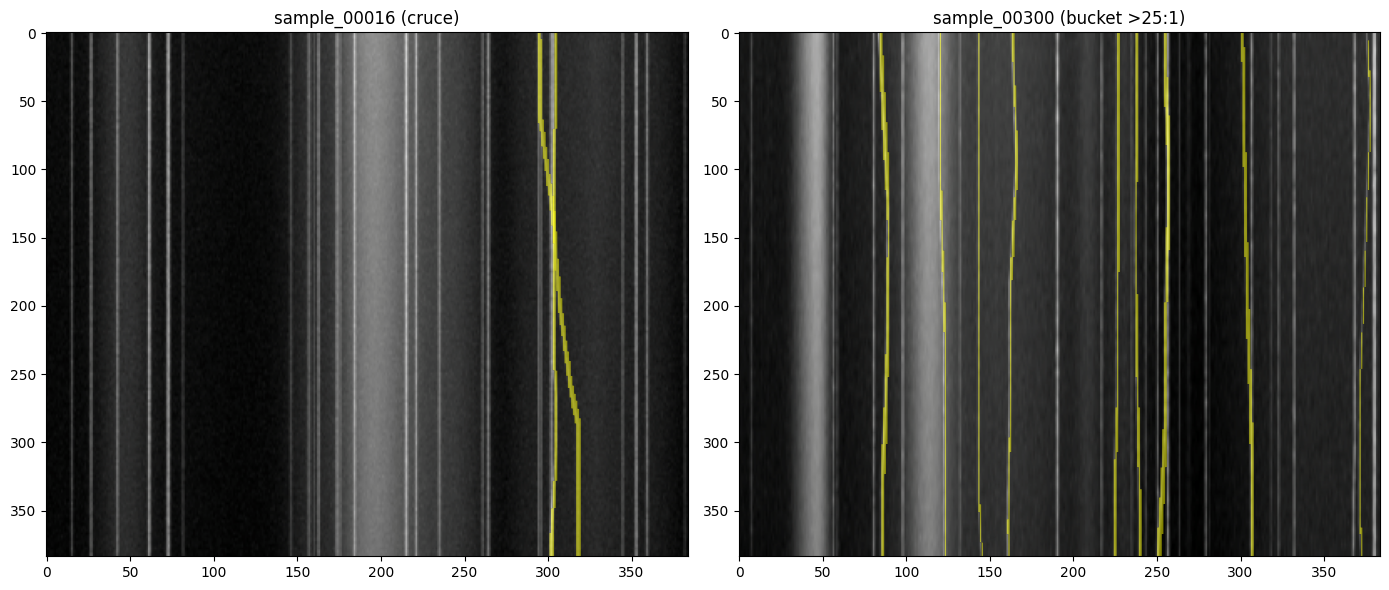

Chequeo visual: las franjas amarillas (mask_labels resizeado) deben caer sobre las trazas moviles visibles en la imagen (pixel_values resizeado, mismo tensor que ve el modelo).


In [21]:
def desnormalizar_pixel_values(pixel_values: torch.Tensor) -> np.ndarray:
    """(3,H,W) normalizado por el processor -> (H,W,3) uint8 visualizable."""
    mean = torch.tensor(processor.image_mean).view(3, 1, 1)
    std = torch.tensor(processor.image_std).view(3, 1, 1)
    img = (pixel_values.cpu() * std + mean).clamp(0, 1)
    return (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)


nombres_angostos = superv_df.loc[superv_df.bucket == ">25:1", "muestra"]
nombre_angosto_23 = nombres_angostos.iloc[0] if len(nombres_angostos) else None
escenas_alineacion = [(escena_demo, f"{escena_demo['nombre']} (cruce)")]
if nombre_angosto_23 is not None:
    escenas_alineacion.append(
        (
            cargar_escena(DATASETS / "test" / nombre_angosto_23),
            f"{nombre_angosto_23} (bucket >25:1)",
        )
    )

fig, axes = plt.subplots(
    1, len(escenas_alineacion), figsize=(7 * len(escenas_alineacion), 6)
)
axes = np.atleast_1d(axes)
for ax, (escena, titulo) in zip(axes, escenas_alineacion):
    inputs, mask_labels, class_labels, instancias = instancias_resize_a_processor(
        escena
    )
    img = desnormalizar_pixel_values(inputs["pixel_values"][0])
    ax.imshow(img, aspect="auto")
    for k, inst in enumerate(instancias):
        if inst.clase != CLASE_MOVIL:
            continue
        m = (mask_labels[k] > 0.5).numpy()
        overlay = np.zeros((*m.shape, 4))
        overlay[m] = (1.0, 1.0, 0.0, 0.5)
        ax.imshow(overlay, aspect="auto")
    ax.set_title(titulo)
plt.tight_layout()
plt.show()
print(
    "Chequeo visual: las franjas amarillas (mask_labels resizeado) deben caer sobre las "
    "trazas moviles visibles en la imagen (pixel_values resizeado, mismo tensor que ve el modelo)."
)

## 3. Sanity-plot de instancias exportadas (checklist paso 3)

`plot_instancias_anotadas` (nueva, en `etiquetas_deteccion.py`) dibuja cada
`InstanciaTraza` con un color **distinto por instancia** (no por clase, a diferencia de
`plot_muestra_anotada`) — la trampa que hay que detectar acá es específica de este
modelo: que las máscaras sigan superpuestas donde corresponde (cruces) en vez de haberse
recortado por un aplanado accidental. Se revisa la muestra con cruce (SS2.1) y una
muestra angosta del bucket `>25:1` (la que más estrés sufre en el resize de SS2.2).


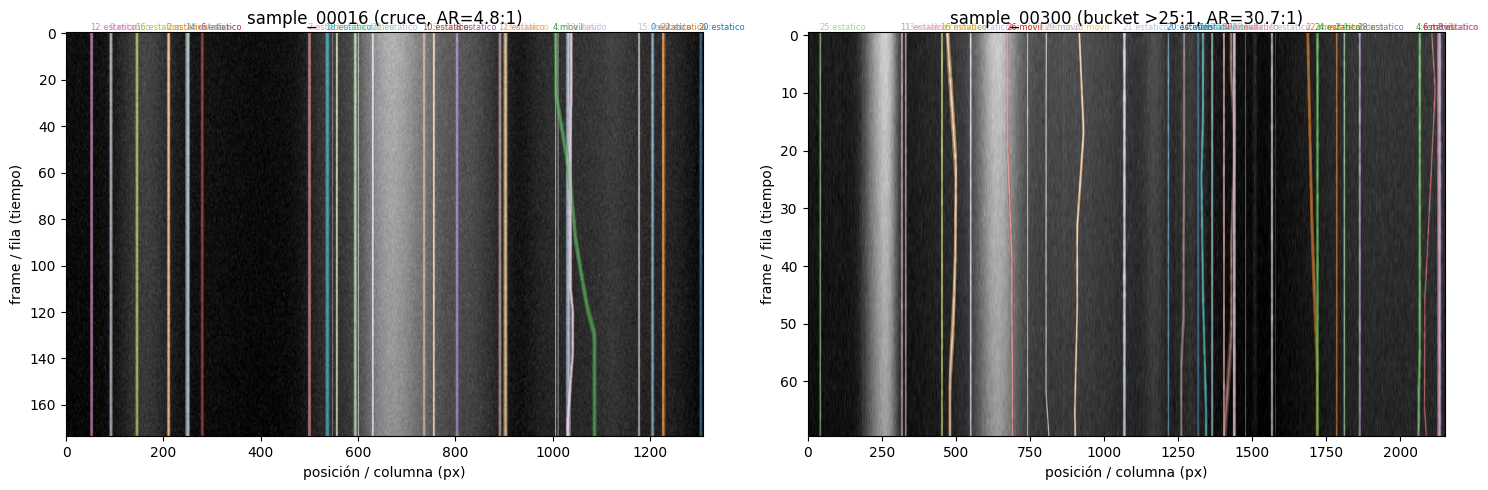

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ed.plot_instancias_anotadas(
    escena_demo["kymo"],
    escena_demo["positions"],
    escena_demo["pixel_scale_um"],
    ax=axes[0],
    min_desplazamiento_px=MIN_DESPLAZAMIENTO_PX,
)
axes[0].set_title(f"{escena_demo['nombre']} (cruce, AR={L/T:.1f}:1)")

muestra_angosta = superv_df.loc[superv_df.bucket == ">25:1", "muestra"]
if len(muestra_angosta):
    nombre_angosta = muestra_angosta.iloc[0]
    escena_angosta = cargar_escena(DATASETS / "test" / nombre_angosta)
    Ta, La = escena_angosta["kymo"].shape
    ed.plot_instancias_anotadas(
        escena_angosta["kymo"],
        escena_angosta["positions"],
        escena_angosta["pixel_scale_um"],
        ax=axes[1],
        min_desplazamiento_px=MIN_DESPLAZAMIENTO_PX,
    )
    axes[1].set_title(f"{nombre_angosta} (bucket >25:1, AR={La/Ta:.1f}:1)")
else:
    axes[1].set_title("(sin muestras >25:1 en este split)")
plt.tight_layout()
plt.show()

## 4. Dataset / collate para Mask2Former

**Simplificación respecto a YOLO/SAM3**: como el `size` del processor es un cuadrado
**fijo** (SS2.2), todas las imágenes de un batch terminan con el mismo `pixel_values`
shape sin importar el ancho original del kymógrafo — a diferencia de NB08/09, que
tuvieron que forzar `batch_size=1` porque `ultralytics`/SAM3 redimensionan distinto
según el ancho de cada muestra. Acá se puede batchear normalmente; lo único variable
por muestra es el número de instancias (`mask_labels`/`class_labels` viajan como listas
de tensores, no como un tensor apilado, tal como espera `forward()`).

**Costo de esa simplificación** (ya cuantificado en SS2.2, no una sorpresa nueva): el
resize a cuadrado fijo distorsiona el aspect ratio de cada kymógrafo — el mismo tipo de
problema geométrico que NB08 §3.1 midió como colapso de recall en YOLO, aunque el
mecanismo de resize es distinto (cuadrado fijo vs. `rect=True`). SS2.2 ya confirmó que
ninguna instancia `movil` desaparece por completo; si el recall estratificado por AR
post-entrenamiento (SS6.1) muestra el mismo colapso >25:1 que NB08, el tiling por
posición de la guía §4.2 es el siguiente paso, no una sorpresa.


In [23]:
class KymografoInstanceDataset(torch.utils.data.Dataset):
    """Envuelve `datasets/{split}/sample_*` -- una escena de synthkymo por item,
    convertida a (pixel_values, pixel_mask, mask_labels, class_labels) para
    `Mask2FormerForUniversalSegmentation.forward()`. `etiquetar_estaticos=False` es la
    re-corrida movers-only experimental de SS2 (un solo parametro, mismos datos); el
    setup principal es el de dos clases (default True)."""

    def __init__(
        self,
        split: str,
        min_desplazamiento_px: float = MIN_DESPLAZAMIENTO_PX,
        limite: int | None = None,
        etiquetar_estaticos: bool = True,
    ):
        muestras = sorted((DATASETS / split).glob("sample_*"))
        self.muestras = muestras[:limite] if limite else muestras
        self.min_desplazamiento_px = min_desplazamiento_px
        self.etiquetar_estaticos = etiquetar_estaticos

    def __len__(self):
        return len(self.muestras)

    def __getitem__(self, idx):
        escena = cargar_escena(self.muestras[idx])
        inputs, mask_labels, class_labels, _ = instancias_resize_a_processor(
            escena,
            self.min_desplazamiento_px,
            etiquetar_estaticos=self.etiquetar_estaticos,
        )
        return {
            "pixel_values": inputs["pixel_values"][0],
            "pixel_mask": inputs["pixel_mask"][0],
            "mask_labels": mask_labels,
            "class_labels": class_labels,
            "nombre": escena["nombre"],
        }


def collate_m2f(batch, device=device):
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]).to(device),
        "pixel_mask": torch.stack([b["pixel_mask"] for b in batch]).to(device),
        "mask_labels": [b["mask_labels"].to(device) for b in batch],
        "class_labels": [b["class_labels"].to(device) for b in batch],
    }


print("KymografoInstanceDataset / collate_m2f definidos")

KymografoInstanceDataset / collate_m2f definidos


## 5. Entrenamiento (WBS 5.2/6.2)

### 5.1 Smoke-test en MPS (checklist paso 4)

Criterio de éxito de la propia guía (§1): **la pérdida baja** en un puñado de pasos
sobre unas pocas imágenes — confirma que el plumbing (datos → forward → backward →
optimizer.step) está bien conectado antes de gastar presupuesto de nube. Se corre acá,
de verdad, sobre datos reales del dataset (no un mock).


8 muestras de smoke-test cargadas
  sample_00000: mask_labels (24, 384, 384), class_labels Counter({1: 22, 0: 2})
  sample_00001: mask_labels (24, 384, 384), class_labels Counter({1: 22, 0: 2})
  sample_00002: mask_labels (24, 384, 384), class_labels Counter({1: 22, 0: 2})
  sample_00003: mask_labels (24, 384, 384), class_labels Counter({1: 22, 0: 2})
  sample_00004: mask_labels (23, 384, 384), class_labels Counter({1: 21, 0: 2})
  sample_00005: mask_labels (24, 384, 384), class_labels Counter({1: 22, 0: 2})
  sample_00006: mask_labels (24, 384, 384), class_labels Counter({1: 22, 0: 2})
  sample_00007: mask_labels (24, 384, 384), class_labels Counter({1: 22, 0: 2})

20 pasos en 8.7s
loss promedio primera mitad: 73.395
loss promedio segunda mitad: 67.794


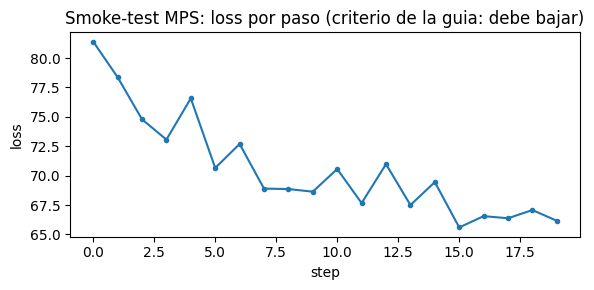


OK: la loss baja -- el plumbing datos -> forward -> backward -> optimizer esta bien conectado.


In [24]:
N_MUESTRAS_SMOKE = 8
N_STEPS_SMOKE = 20

dataset_smoke = KymografoInstanceDataset("train", limite=N_MUESTRAS_SMOKE)
ejemplos_smoke = [dataset_smoke[i] for i in range(len(dataset_smoke))]
print(f"{len(ejemplos_smoke)} muestras de smoke-test cargadas")
for e in ejemplos_smoke:
    print(
        f"  {e['nombre']}: mask_labels {tuple(e['mask_labels'].shape)}, "
        f"class_labels {Counter(e['class_labels'].tolist())}"
    )

modelo.train()
optim = torch.optim.AdamW(modelo.parameters(), lr=1e-5)

t0 = time.time()
losses_smoke = []
for step in range(N_STEPS_SMOKE):
    batch = collate_m2f([ejemplos_smoke[step % len(ejemplos_smoke)]])
    optim.zero_grad()
    out = modelo(
        pixel_values=batch["pixel_values"],
        pixel_mask=batch["pixel_mask"],
        mask_labels=batch["mask_labels"],
        class_labels=batch["class_labels"],
    )
    out.loss.backward()
    optim.step()
    losses_smoke.append(float(out.loss.detach().cpu()))

print(f"\n{N_STEPS_SMOKE} pasos en {time.time() - t0:.1f}s")
mitad = N_STEPS_SMOKE // 2
print(f"loss promedio primera mitad: {np.mean(losses_smoke[:mitad]):.3f}")
print(f"loss promedio segunda mitad: {np.mean(losses_smoke[mitad:]):.3f}")

plt.figure(figsize=(6, 3))
plt.plot(losses_smoke, marker="o", ms=3)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Smoke-test MPS: loss por paso (criterio de la guia: debe bajar)")
plt.tight_layout()
plt.show()

assert np.mean(losses_smoke[mitad:]) < np.mean(losses_smoke[:mitad]), (
    "el smoke-test deberia mostrar la loss bajando -- si no, el bug esta probablemente "
    "en la alineacion mascara/imagen (SS2), no en el modelo"
)
print(
    "\nOK: la loss baja -- el plumbing datos -> forward -> backward -> optimizer esta bien conectado."
)

### 5.2 Fine-tune completo (cloud/cluster) — **no ejecutado en este notebook**

El smoke-test de arriba corrió sobre 8 muestras y 20 pasos en CPU/MPS local — confirma
que el código funciona, no produce un modelo entrenado. El fine-tune real (todo
`train`/`val`, early stopping por validation loss, congelar el backbone Swin las
primeras épocas y descongelarlo después, panel fijo de muestras difíciles/cruces cada
pocas épocas) necesita GPU de nube o cluster dentro del presupuesto de ~50 USD/mes del
proyecto — gastar ese presupuesto es una decisión del usuario, no de este notebook. La
celda de abajo deja el loop completo escrito y lo salta por default
(`EJECUTAR_FINE_TUNE_COMPLETO = False`); poner esa bandera en `True` en un entorno con
GPU (o el cluster, si el acceso está confirmado) lo corre tal cual.


In [25]:
EJECUTAR_FINE_TUNE_COMPLETO = True  # poner en True en un entorno con GPU real
CONTINUAR_DESDE_BEST = True  # True: reanudar desde results/mask2former/best si existe

N_EPOCHS = 100  # tope generoso -- el early stopping (PATIENCE) decide el final real
EPOCAS_BACKBONE_CONGELADO = 3  # solo aplica a un run FRESCO desde el checkpoint de COCO
LR = 1e-5
BATCH_SIZE = 4
PATIENCE = 5  # early stopping por validation loss
RUTA_MEJOR_MODELO = RAIZ / "results" / "mask2former" / "best"


def congelar_backbone(modelo, congelar: bool):
    for p in modelo.model.pixel_level_module.encoder.parameters():
        p.requires_grad = not congelar


def _val_loss_promedio(modelo, val_dl):
    modelo.eval()
    losses = []
    with torch.no_grad():
        for batch in val_dl:
            losses.append(float(modelo(**batch).loss.cpu()))
    return float(np.mean(losses))


def fine_tune_completo():
    global modelo  # al final se recargan los MEJORES pesos sobre esta variable (ver abajo)

    reanudando = (
        CONTINUAR_DESDE_BEST and (RUTA_MEJOR_MODELO / "model.safetensors").exists()
    )
    if reanudando:
        # los pesos se retoman del mejor checkpoint; el estado de AdamW no se guardo,
        # asi que el optimizador arranca limpio -- aceptable con LR constante y chico
        modelo = Mask2FormerForUniversalSegmentation.from_pretrained(
            RUTA_MEJOR_MODELO
        ).to(device)
        print(f"reanudando desde {RUTA_MEJOR_MODELO}")

    train_ds = KymografoInstanceDataset("train")
    val_ds = KymografoInstanceDataset("val")
    train_dl = torch.utils.data.DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_m2f
    )
    val_dl = torch.utils.data.DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_m2f
    )

    optim = torch.optim.AdamW(modelo.parameters(), lr=LR)
    if reanudando:
        # baseline ANTES de entrenar: si la primera epoca del run nuevo sale peor que el
        # checkpoint cargado, NO debe pisarlo en disco
        mejor_val_loss = _val_loss_promedio(modelo, val_dl)
        print(
            f"val_loss del checkpoint cargado (baseline a superar): {mejor_val_loss:.4f}"
        )
    else:
        mejor_val_loss = float("inf")
    epocas_sin_mejora = 0

    for epoch in range(N_EPOCHS):
        # el congelado inicial del backbone es un truco de estabilidad para el arranque
        # desde COCO; al reanudar, el backbone ya se entreno descongelado -- no re-congelar
        congelar_backbone(
            modelo, congelar=(not reanudando) and epoch < EPOCAS_BACKBONE_CONGELADO
        )
        modelo.train()
        for batch in train_dl:
            optim.zero_grad()
            out = modelo(**batch)
            out.loss.backward()
            optim.step()

        val_loss = _val_loss_promedio(modelo, val_dl)
        print(f"epoch {epoch:02d}  val_loss={val_loss:.4f}")

        if val_loss < mejor_val_loss:
            mejor_val_loss, epocas_sin_mejora = val_loss, 0
            modelo.save_pretrained(RUTA_MEJOR_MODELO)
            processor.save_pretrained(RUTA_MEJOR_MODELO)  # checkpoint autosuficiente
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= PATIENCE:
                print(f"early stopping en epoch {epoch}")
                break

        # TODO panel de muestras dificiles (cruces/densas) cada pocas epocas -- SS3 de
        # la guia: el loss curve no muestra fallos de identidad, un panel cualitativo si.

    # El early stopping deja en memoria los pesos de la ULTIMA epoca (hasta PATIENCE
    # epocas peores que el mejor val_loss). La seccion 6 evalua `modelo`, asi que hay
    # que recargar el mejor checkpoint antes de salir -- si no, se mediria el modelo
    # equivocado.
    modelo = Mask2FormerForUniversalSegmentation.from_pretrained(RUTA_MEJOR_MODELO).to(
        device
    )
    print(
        f"mejores pesos recargados desde {RUTA_MEJOR_MODELO} (val_loss={mejor_val_loss:.4f})"
    )


if EJECUTAR_FINE_TUNE_COMPLETO:
    fine_tune_completo()
else:
    print(
        "EJECUTAR_FINE_TUNE_COMPLETO=False -- fine-tune completo NO corrido en este notebook."
    )
    print("Correr en un entorno con GPU (cloud/cluster) poniendo la bandera en True.")

Loading weights:   0%|          | 0/556 [00:00<?, ?it/s]

reanudando desde /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/results/mask2former/best
val_loss del checkpoint cargado (baseline a superar): 26.0490
epoch 00  val_loss=25.8660


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 01  val_loss=25.9225
epoch 02  val_loss=25.8671
epoch 03  val_loss=25.7217


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

epoch 20  val_loss=24.7419


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 21  val_loss=24.7482
epoch 22  val_loss=25.1147
epoch 23  val_loss=24.7741
epoch 24  val_loss=24.7707
epoch 25  val_loss=24.7430
early stopping en epoch 25


Loading weights:   0%|          | 0/556 [00:00<?, ?it/s]

mejores pesos recargados desde /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/results/mask2former/best (val_loss=24.7419)


## 6. Evaluación

Reuso del harness de NB09 (extraído verbatim a `src/axonal_tracking/evaluacion.py`,
ver su docstring) más el patrón de recall estratificado por aspect ratio de NB08 §3.1.

**Aviso importante**: el modelo usado en esta sección es el del smoke-test de SS5.1 (20
pasos sobre 8 muestras) — **no** un modelo entrenado. Los números de acá sirven
únicamente para confirmar que el pipeline de evaluación ejecuta de punta a punta sobre
salidas reales del modelo; no son una medición de si Mask2Former resuelve identidad en
cruces. Esa medición (la que decide el gate de la guía §6) requiere el fine-tune
completo de SS5.2.

**Sin cajas de un detector externo**: a diferencia de NB09 (donde `own_id` de cada
máscara venía gratis del match YOLO-caja→GT-caja), acá cada query predice una máscara
sin target asignado de antemano. La asignación predicción→GT se hace por IoU de
**máscara** (`ev.emparejar_greedy` con `ev.iou_mascara`) — el análogo directo del
matching por IoU de caja que usaba NB09.

**Filtrar por clase `movil` es obligatorio, no cosmético**: `post_process_instance_segmentation`
devuelve una máscara por cada query aceptada, `movil` **y** `estatico` mezcladas
(~2 vs ~22 por escena). Si no se filtra por `segments_info[i]["label_id"]`, las
`~22` queries `estatico` de cada escena entran a competir por el match contra el GT
móvil y contaminan precision/§6.3 con polilíneas que no tienen nada que ver con la
hipótesis bajo prueba. `predecir_instancias` filtra esto explícitamente.

**Máscaras "crudas"**: se usa `post_process_instance_segmentation(..., return_binary_maps=True)`,
que devuelve la máscara binaria de cada query por separado (score >= threshold, sin
fusionar/arbitrar píxel a píxel). Es el análogo de `masks_A_raw` de NB09 — y, a
diferencia de SAM3 (que sí tenía una variante arbitrada `masks_A` vía
`apply_non_overlapping_constraints`), acá no hay una segunda variante "arbitrada"
razonable que usar: el `segmentation` plano que devuelve el processor por default
resuelve el solape con un orden de inserción arbitrario (no por confianza, ver el
código fuente de `post_process_instance_segmentation`), así que usarlo daría una
competencia por píxel espuria, no la competencia real que aprendieron las queries
durante el entrenamiento. Se documenta y se usa un solo objeto de máscara por query
para todo SS6.

**`frac_own` con un piso de IoU puede subestimar la falla que mide**: acá `own_id` sale
de emparejar por IoU de máscara (`iou_thr=0.3`) contra el GT — a diferencia de NB09,
donde el `own_id` venía gratis del match de **caja** (una máscara que derivaba hacia el
vecino igual quedaba "adentro" porque la caja sí matcheaba). Si una query predice una
máscara que abarca dos tracks GT a la vez (exactamente la falla de identidad que
`frac_own` existe para medir), puede no llegar a 0.3 de IoU contra **ninguno** de los
dos y quedar descartada antes de contar — inflando artificialmente `frac_own` sobre el
subconjunto que sí queda. SS6.2 cuenta esto explícitamente (predicciones sin match que
solapan ≥2 GT móviles) para poder leer el número con ese sesgo en mente.


### 6.0 Correr el modelo una vez por muestra (evita repetir inferencia en 6.1/6.2/6.3)


In [26]:
def predecir_instancias(escena: dict, threshold: float = 0.3):
    """Corre el modelo sobre una escena y devuelve SOLO las mascaras clasificadas como
    MOVIL (filtrando por segments_info/label_id -- ver aviso de SS6: mezclar movil y
    estatico contamina el matching contra GT movil), una por query por encima de
    threshold, sin fusionar, en el tamano ORIGINAL del kymografo. Si ninguna query
    supera el threshold, `segments_info` viene vacio y se devuelve `[]` -- filtrar por
    `segments_info` (en vez de indexar `segmentation` a ciegas) es lo que evita el caso
    borde donde `post_process_instance_segmentation` deja `segmentation` como el mapa
    2D `(T, L)` sin instancias en vez de un stack (N, T, L) (ver su codigo fuente)."""
    T, L = escena["kymo"].shape
    rgb = ed.kymografo_a_rgb_uint8(escena["kymo"])
    inputs = processor(images=rgb, return_tensors="pt").to(device)
    modelo.eval()
    with torch.no_grad():
        out = modelo(
            pixel_values=inputs["pixel_values"], pixel_mask=inputs["pixel_mask"]
        )
    resultado = processor.post_process_instance_segmentation(
        out,
        threshold=threshold,
        target_sizes=[(T, L)],
        return_binary_maps=True,
    )[0]
    segments_info = resultado["segments_info"]
    if not segments_info:
        return []
    seg = resultado[
        "segmentation"
    ]  # (n_queries_aceptadas, T, L), indexado igual que segments_info
    return [
        seg[i].cpu().numpy().astype(bool)
        for i, info in enumerate(segments_info)
        if info["label_id"] == CLASE_MOVIL
    ]


N_MUESTRAS_EVAL = (
    40  # subconjunto chico -- solo para probar el plumbing (ver aviso de SS6)
)
muestras_eval = sorted((DATASETS / "test").glob("sample_*"))[:N_MUESTRAS_EVAL]

escenas_cache = {s.name: cargar_escena(s) for s in muestras_eval}
predicciones_cache = {
    nombre: predecir_instancias(e) for nombre, e in escenas_cache.items()
}
print(
    f"{len(escenas_cache)} escenas cargadas, predicciones (solo clase movil) cacheadas -- "
    f"{sum(len(v) for v in predicciones_cache.values())} mascaras movil predichas en total"
)

40 escenas cargadas, predicciones (solo clase movil) cacheadas -- 116 mascaras movil predichas en total


### 6.1 Recall estratificado por aspect ratio (NB08 §3.1, sobre el modelo del smoke-test)


In [27]:
def cajas_desde_mascara(mask: np.ndarray) -> tuple[float, float, float, float] | None:
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    return (float(xs.min()), float(ys.min()), float(xs.max()) + 1, float(ys.max()) + 1)


filas_ar = []
for nombre, escena in escenas_cache.items():
    T, L = escena["kymo"].shape
    cajas_gt = ed.cajas_desde_positions(
        escena["positions"],
        escena["pixel_scale_um"],
        (T, L),
        min_desplazamiento_px=MIN_DESPLAZAMIENTO_PX,
    )
    gt_movil = [(c.x1, c.y1, c.x2, c.y2) for c in cajas_gt if c.clase == CLASE_MOVIL]

    masks_pred = predicciones_cache[nombre]
    cajas_pred = [b for m in masks_pred if (b := cajas_desde_mascara(m)) is not None]

    match = ev.emparejar_greedy(cajas_pred, gt_movil, ev.iou_caja, iou_thr=0.3)
    recall = len({j for j in match if j is not None}) / max(len(gt_movil), 1)
    filas_ar.append(
        {
            "muestra": nombre,
            "aspect_ratio": L / T,
            "bucket": bucket_ar(L / T),
            "recall_movil": recall,
            "n_gt_movil": len(gt_movil),
        }
    )

ar_eval_df = pd.DataFrame(filas_ar)
print(f"{len(ar_eval_df)} muestras evaluadas (SMOKE-TEST, plumbing check unicamente)")
ar_eval_df.groupby("bucket").agg(
    n_muestras=("muestra", "count"),
    recall_movil=("recall_movil", "mean"),
    n_gt_movil=("n_gt_movil", "sum"),
).round(3).reindex(ORDEN_BUCKETS)

40 muestras evaluadas (SMOKE-TEST, plumbing check unicamente)


,n_muestras,recall_movil,n_gt_movil
bucket,,,
<8:1,32.0,0.922,64.0
8-15:1,8.0,0.938,16.0
15-25:1,NaN,NaN,NaN
>25:1,NaN,NaN,NaN


### 6.2 Métricas a nivel máscara: recall/precision/leakage + diagnóstico de identidad

Mismas métricas que NB09 §6 (`ev.evaluar_mascara`, `ev.nearest_particle_per_row`,
`ev.resumen_identidad`) y el flag de ambigüedad de §7 (`ev.flaggear_cruces`), sobre las
máscaras "crudas" del modelo del smoke-test. Se agrega un contador que NB09 no
necesitaba (ver aviso de SS6, "`frac_own` con un piso de IoU..."): cuántas predicciones
quedan **sin** match (por debajo de `iou_thr=0.3` contra todo el GT) pero igual solapan
a **2 o más** partículas GT móviles — el indicio directo de que el piso de IoU está
descartando justo las máscaras de identidad mezclada antes de que lleguen a contarse.


In [28]:
filas_m2f = []
flags_m2f = []
sin_match_multi_gt = 0
sin_match_total = 0
for nombre, escena in escenas_cache.items():
    T, L = escena["kymo"].shape
    px = escena["pixel_scale_um"]
    ids_mov = ed.ids_que_se_mueven(escena["positions"], px, MIN_DESPLAZAMIENTO_PX)
    movers = escena["positions"][escena["positions"]["particle_id"].isin(ids_mov)]
    masks_gt = {
        pid: ed.mascara_traza(escena["positions"], pid, px, (T, L)) for pid in ids_mov
    }

    masks_pred = predicciones_cache[nombre]
    if not masks_pred:
        continue
    ids_gt_lista = list(masks_gt.keys())
    match = ev.emparejar_greedy(
        masks_pred, list(masks_gt.values()), ev.iou_mascara, iou_thr=0.3
    )
    ids_matched = [ids_gt_lista[j] if j is not None else -1 for j in match]

    flags_m2f += ev.flaggear_cruces(masks_pred, nombre, ids_matched)

    for i, pid in enumerate(ids_matched):
        if pid == -1:
            sin_match_total += 1
            n_gt_solapados = sum(
                1 for m in masks_gt.values() if (masks_pred[i] & m).any()
            )
            if n_gt_solapados >= 2:
                sin_match_multi_gt += 1
            continue
        gt_propia = masks_gt[pid]
        gt_otras = np.zeros((T, L), dtype=bool)
        for otro_pid, m in masks_gt.items():
            if otro_pid != pid:
                gt_otras |= m
        m_eval = ev.evaluar_mascara(masks_pred[i], gt_propia, gt_otras)
        ident = ev.resumen_identidad(
            ev.nearest_particle_per_row(masks_pred[i], movers, T, px, L), pid
        )
        filas_m2f.append(
            {"muestra": nombre, "caja": i, "particle_id": pid, **m_eval, **ident}
        )

eval_m2f_df = pd.DataFrame(filas_m2f)
flags_m2f_df = pd.DataFrame(flags_m2f)

print(f"predicciones SIN match a GT (IoU < 0.3 contra todo el GT): {sin_match_total}")
print(
    f"  de esas, solapan >=2 GT moviles a la vez (candidata a identidad mezclada, "
    f"excluida de frac_own abajo): {sin_match_multi_gt}"
)

if len(eval_m2f_df) == 0:
    # esperable con el modelo del smoke-test (20 pasos): al filtrar SOLO clase movil
    # (arreglo de esta seccion), puede que ninguna mascara movil predicha llegue a
    # iou_thr=0.3 contra el GT -- no hay nada que promediar todavia, no es un error.
    print(
        "\n0 pares (mascara movil predicha, GT) con match -- esperable en el smoke-test, "
        "no hay metricas de SS6.2 que calcular hasta el fine-tune completo de SS5.2."
    )
else:
    eval_m2f_df["switch_rate"] = eval_m2f_df["cambios_identidad"] / eval_m2f_df[
        "n_filas"
    ].clip(lower=1)
    print(
        f"{len(eval_m2f_df)} pares (mascara, GT) evaluados sobre {len(escenas_cache)} muestras (SMOKE-TEST)"
    )
    print(
        eval_m2f_df[
            ["recall", "precision", "leakage", "area_frac", "switch_rate", "frac_own"]
        ]
        .mean()
        .round(3)
    )
    print(f"\nfraccion degeneradas: {eval_m2f_df['degenerada'].mean():.3f}")
    print(
        f"{len(flags_m2f_df)} pares de mascaras flaggeados como ambiguos "
        f"(IoU cruda >= {ev.IOU_AMBIGUO})"
        if len(flags_m2f_df)
        else "0 pares ambiguos flaggeados"
    )

    if len(flags_m2f_df):
        amb = set()
        for r in flags_m2f_df.itertuples():
            if r.ambos_matcheados:
                amb.add((r.muestra, r.caja_i))
                amb.add((r.muestra, r.caja_j))
        eval_m2f_df["ambigua"] = [
            (m, c) in amb for m, c in zip(eval_m2f_df["muestra"], eval_m2f_df["caja"])
        ]
        print(
            "\npor subgrupo ambiguo vs no-ambiguo (comparable a NB09 SS7.1, cuando haya un modelo entrenado):"
        )
        print(
            eval_m2f_df.groupby("ambigua")[["switch_rate", "frac_own", "recall"]]
            .mean()
            .round(3)
        )

predicciones SIN match a GT (IoU < 0.3 contra todo el GT): 49
  de esas, solapan >=2 GT moviles a la vez (candidata a identidad mezclada, excluida de frac_own abajo): 5
67 pares (mascara, GT) evaluados sobre 40 muestras (SMOKE-TEST)
recall         0.775
precision      0.618
leakage        0.006
area_frac      0.009
switch_rate    0.001
frac_own       0.991
dtype: float64

fraccion degeneradas: 0.000
31 pares de mascaras flaggeados como ambiguos (IoU cruda >= 0.1)

por subgrupo ambiguo vs no-ambiguo (comparable a NB09 SS7.1, cuando haya un modelo entrenado):
         switch_rate  frac_own  recall
ambigua                               
False          0.001     0.991   0.775


### 6.3 Evaluación a nivel trayectoria

`ev.evaluar_trayectorias` — mismo criterio de asociación que `comparar_tracks()` de
NB06 (`thr_px_track=4.0`, `min_overlap_filas=10`), reusado verbatim.


In [29]:
escenas_m2f = {
    nombre: {
        "kymo": escena["kymo"],
        "positions": escena["positions"],
        "pixel_scale_um": escena["pixel_scale_um"],
        "fps": escena["fps"],
        "masks_m2f": predicciones_cache[nombre],
    }
    for nombre, escena in escenas_cache.items()
}

tr_m2f_df, resumen_m2f = ev.evaluar_trayectorias(
    escenas_m2f, "masks_m2f", min_desplazamiento_px=MIN_DESPLAZAMIENTO_PX
)
print(
    "Resumen de trayectorias (SMOKE-TEST -- numeros de plumbing check, no de un modelo entrenado):"
)
for k, v in resumen_m2f.items():
    print(f"  {k}: {v}")

Resumen de trayectorias (SMOKE-TEST -- numeros de plumbing check, no de un modelo entrenado):
  n_polilineas: 116
  n_gt_moviles: 80
  track_recall: 0.938
  track_precision: 0.862
  track_f1: 0.898
  err_pos_px_medio: 1.14
  err_pos_um_medio: 0.122
  err_vel_um_s_medio: 0.022
  err_vel_um_s_mediana: 0.007
  frac_id_switch: 0.052


### 6.4 Panel cualitativo: ¿el modelo _sigue_ cada traza, o solo encuentra píxeles?

Las métricas de 6.1–6.3 comprimen justo lo que hay que mirar con los ojos: si cada
máscara predicha sigue **una** traza a través de los cruces (la hipótesis de la guía §0)
o se fragmenta/mezcla. Este panel muestra, por muestra, dos filas alineadas:

- **arriba**: máscaras `movil` predichas, un color por instancia, con su polilínea
  subpixel (`ev.extraer_subpixel`) encima; las predicciones `estatico` en blanco tenue
  (para ver que el modelo las explica aparte, el motivo de la decisión de 2 clases).
- **abajo**: las máscaras GT móviles, pintadas del **mismo color que la predicción
  emparejada** (IoU de máscara ≥ 0.3); GT sin emparejar queda en blanco con la marca
  "NO recuperada".

Si el modelo trackea bien, cada color de arriba cae sobre exactamente un color igual
abajo, también a través de los cruces. Selección deliberada de muestras (no aleatoria):
las 3 con más píxeles de cruce del test, la más ancha (bucket >25:1), la más densa,
más la muestra demo con cruce de SS2.1 y una muestra típica fácil — los extremos donde
un fallo de identidad se ve, y el caso normal como referencia. (El escaneo de selección
recorre todo el test una vez, ~1–2 min.)


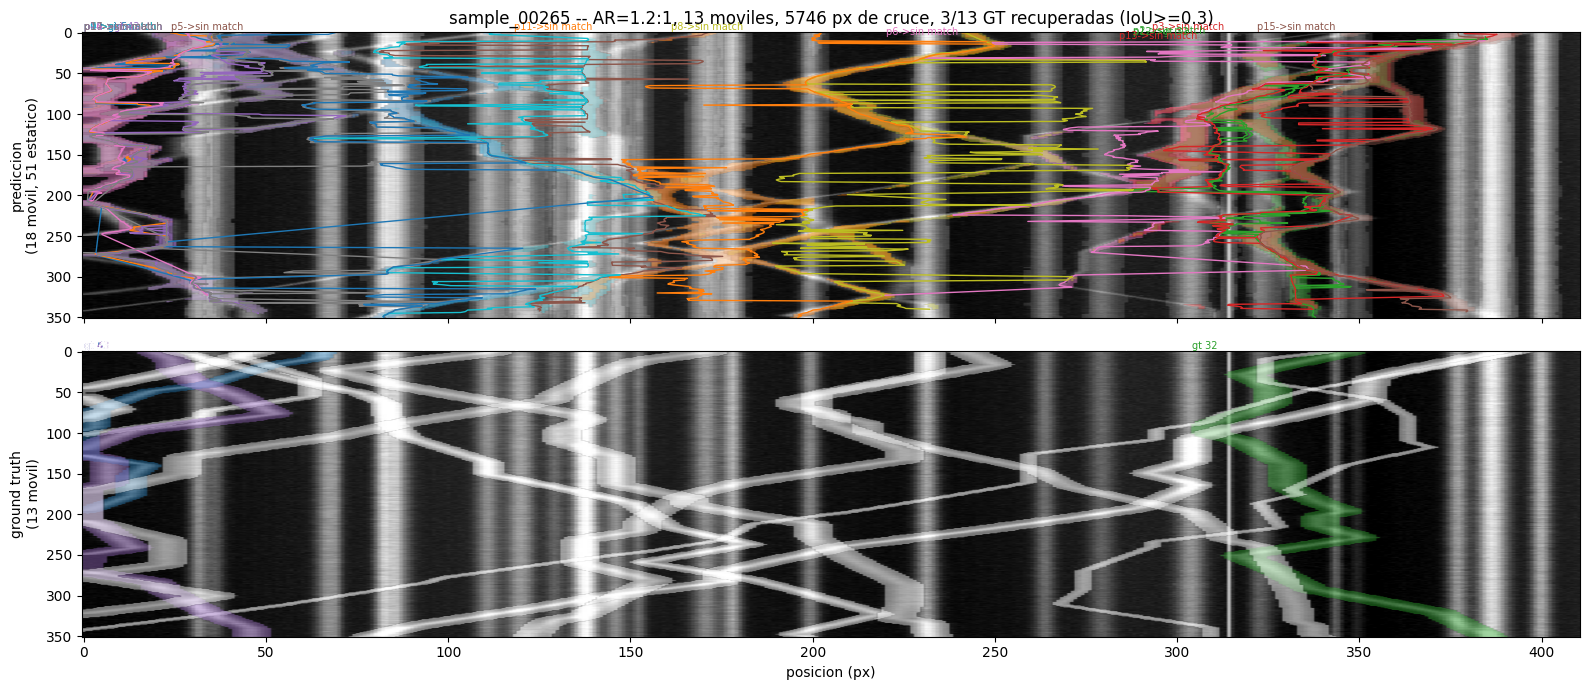

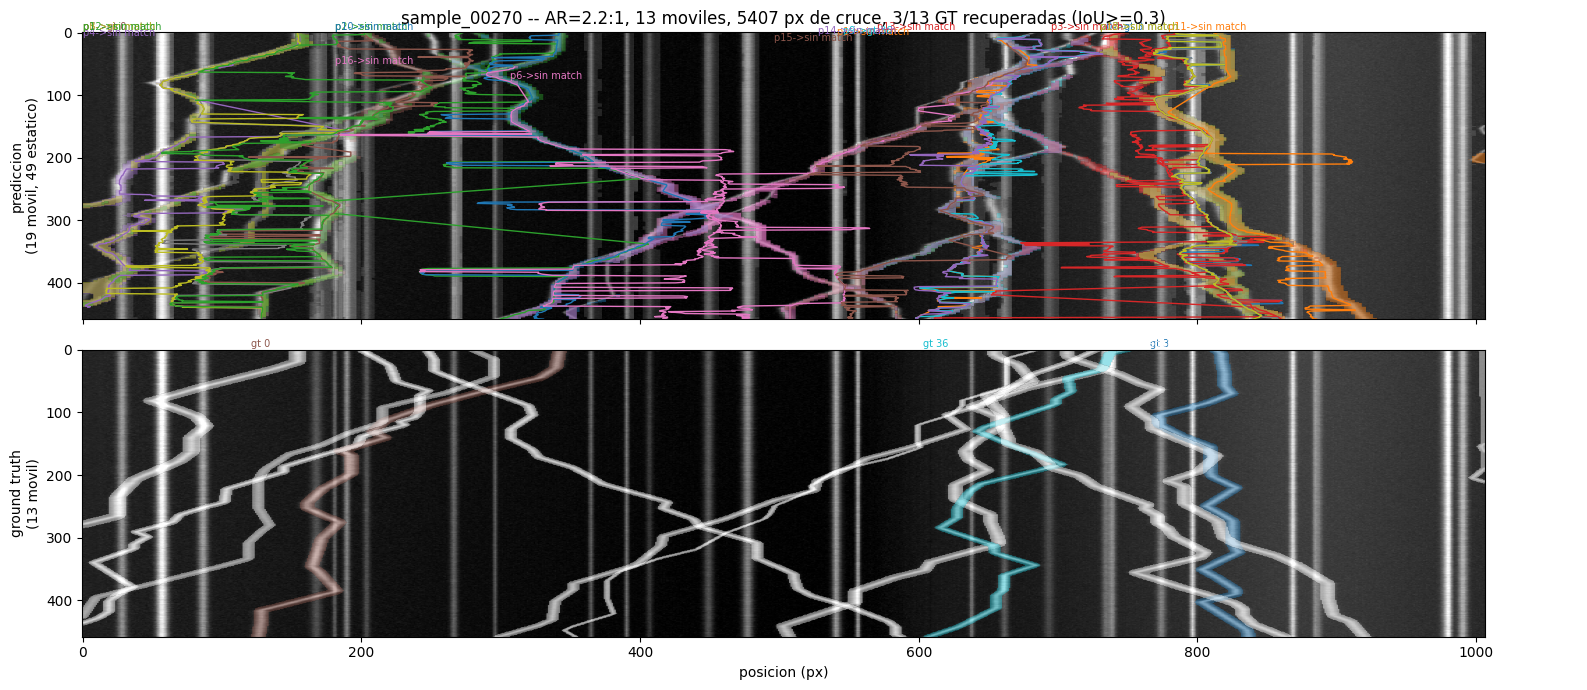

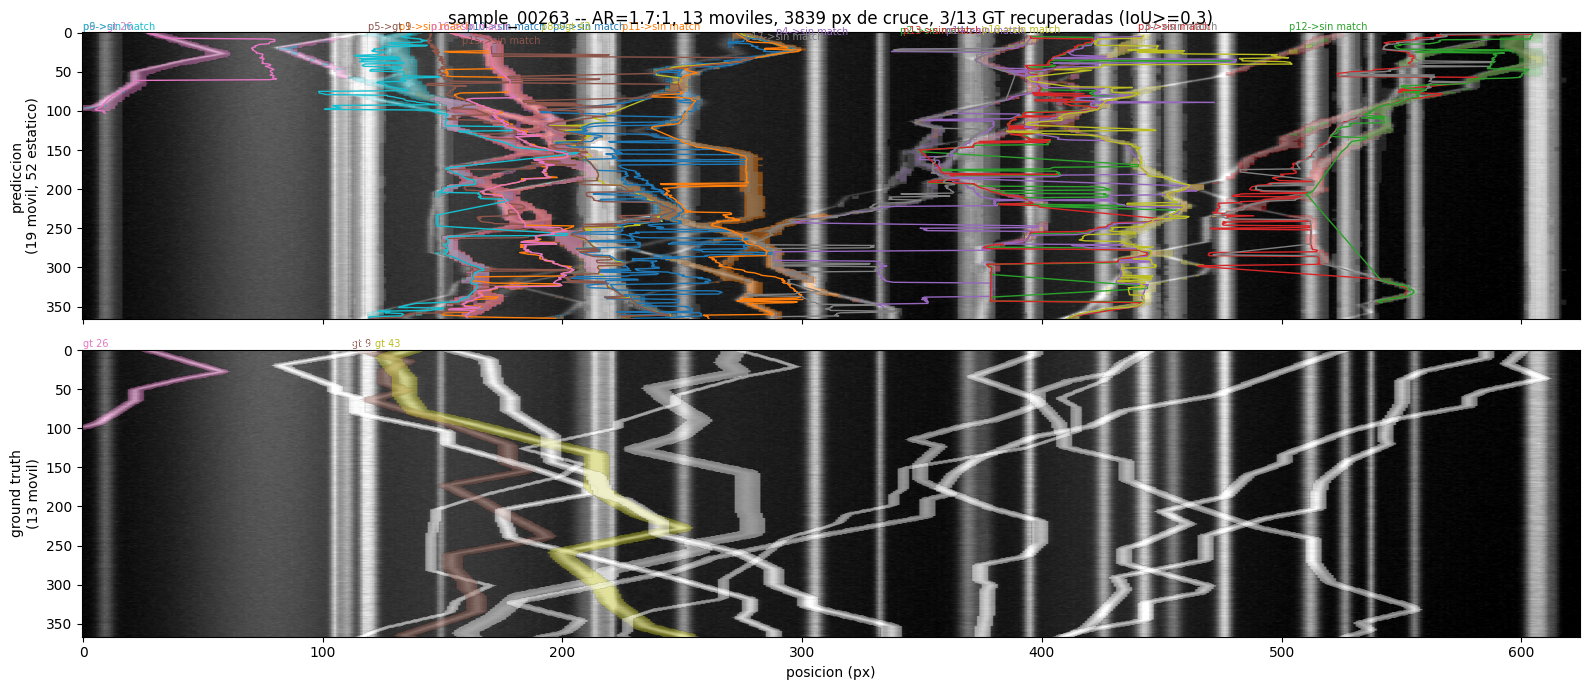

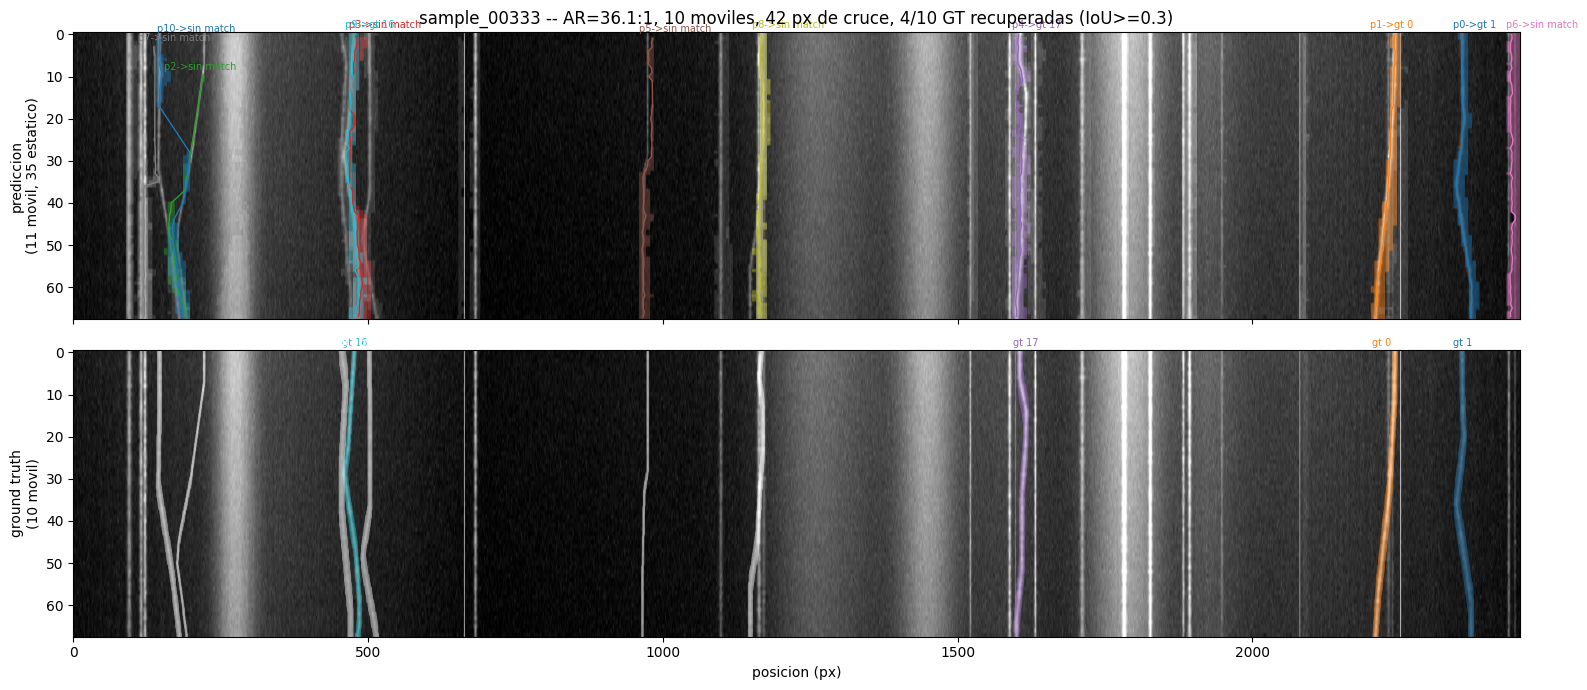

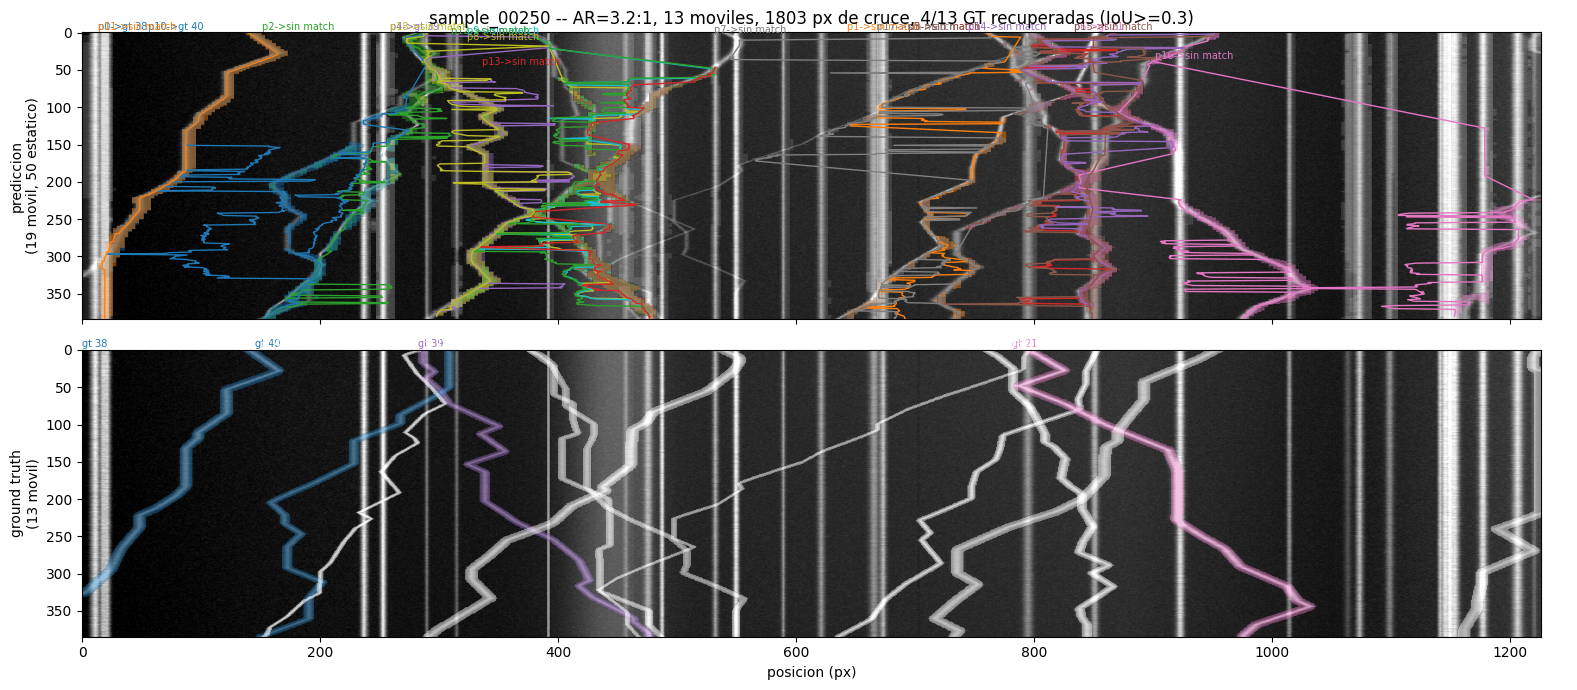

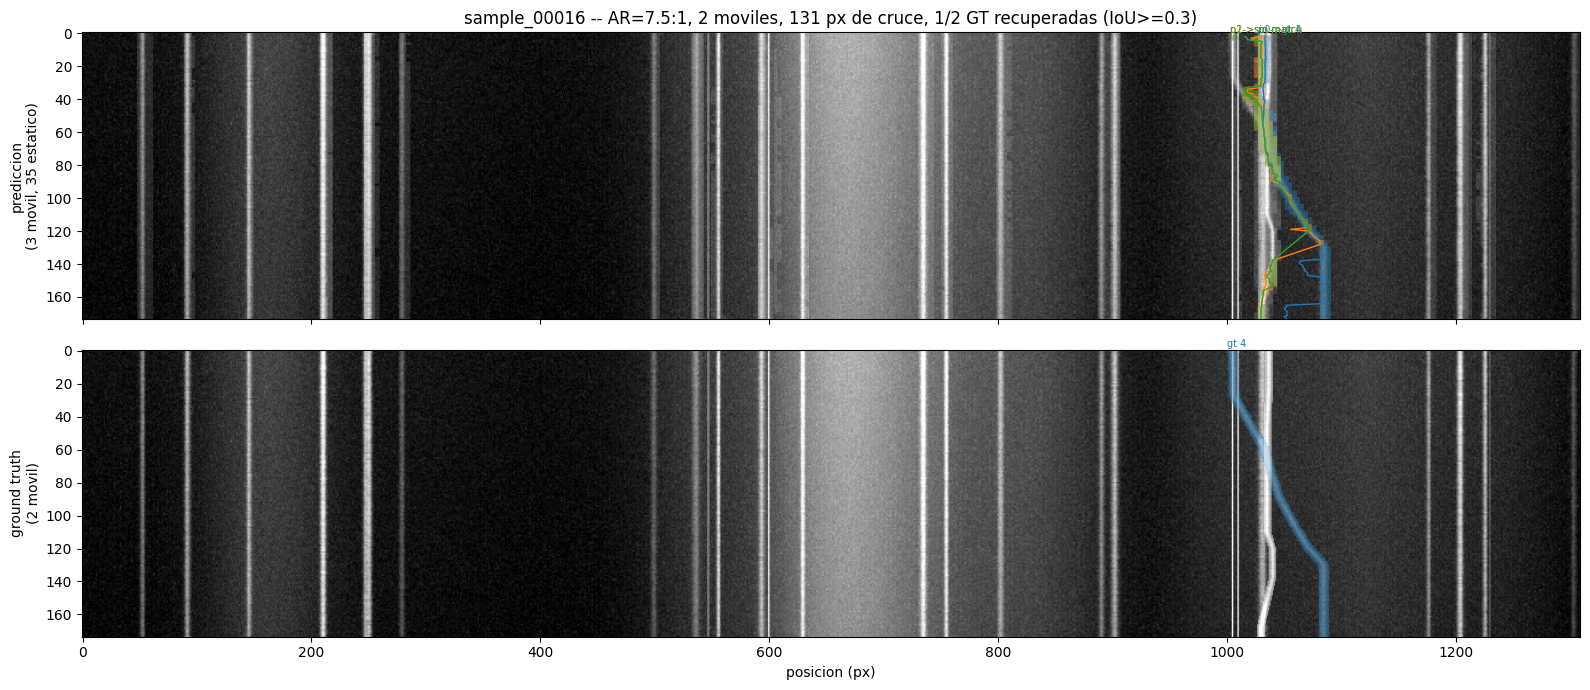

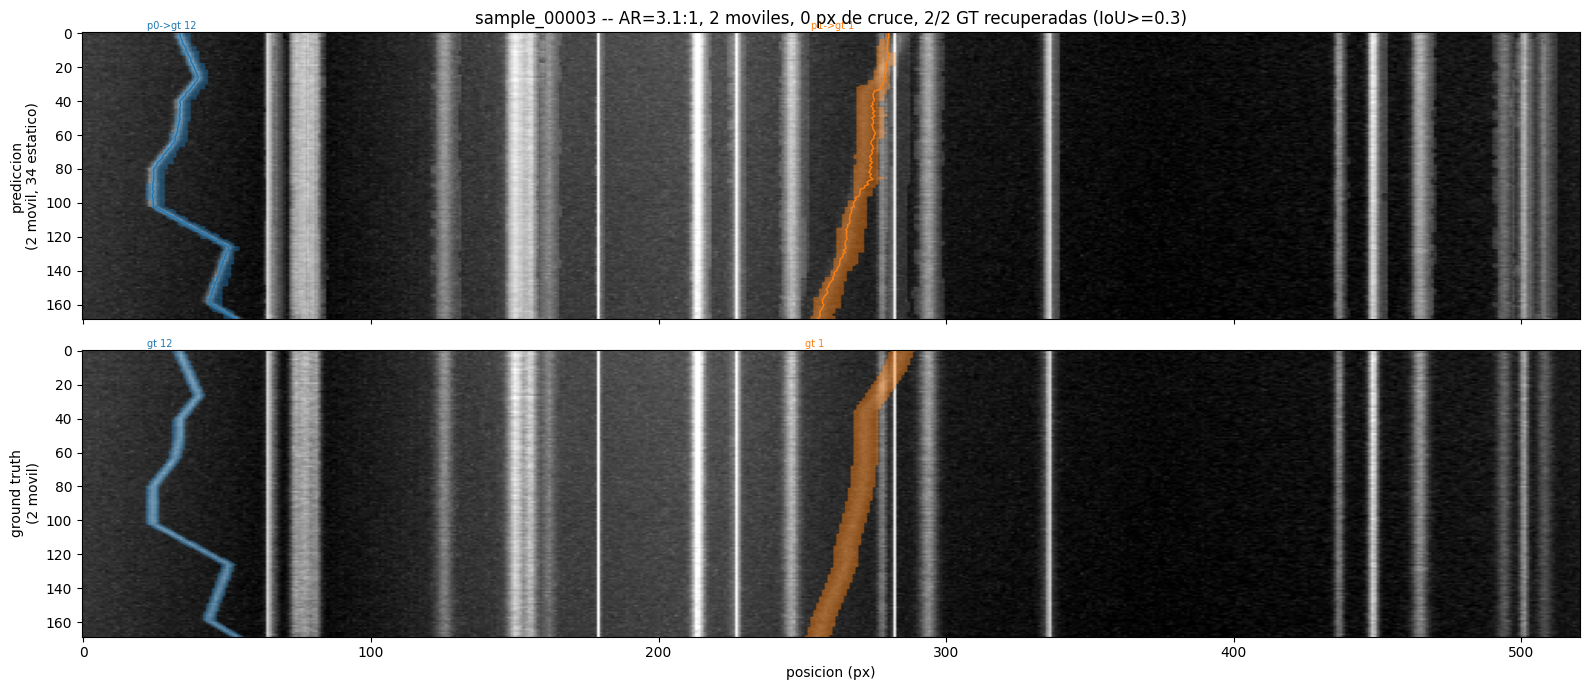

In [30]:
def panel_pred_vs_gt(escena: dict, ax_p, ax_g, threshold: float = 0.3):
    """Dos filas alineadas: predicciones movil coloreadas + polilinea (arriba) vs GT
    movil con el color de su prediccion emparejada (abajo). Ver markdown de SS6.4."""
    T, L = escena["kymo"].shape
    px = escena["pixel_scale_um"]
    kymo = escena["kymo"]
    vmin, vmax = np.percentile(kymo, 1), np.percentile(kymo, 99.5)

    # todas las queries aceptadas, separadas por clase (predecir_instancias devuelve
    # solo movil; aca tambien se muestran las estatico, en tenue)
    rgb = ed.kymografo_a_rgb_uint8(kymo)
    inputs = processor(images=rgb, return_tensors="pt").to(device)
    modelo.eval()
    with torch.no_grad():
        out = modelo(
            pixel_values=inputs["pixel_values"], pixel_mask=inputs["pixel_mask"]
        )
    res = processor.post_process_instance_segmentation(
        out, threshold=threshold, target_sizes=[(T, L)], return_binary_maps=True
    )[0]
    si = res["segments_info"]
    seg = res["segmentation"] if si else None
    pred_mov = [
        seg[i].cpu().numpy().astype(bool)
        for i, s in enumerate(si)
        if s["label_id"] == CLASE_MOVIL
    ]
    pred_est = [
        seg[i].cpu().numpy().astype(bool)
        for i, s in enumerate(si)
        if s["label_id"] == CLASE_ESTATICO
    ]

    ids_mov = ed.ids_que_se_mueven(escena["positions"], px, MIN_DESPLAZAMIENTO_PX)
    masks_gt = {
        pid: ed.mascara_traza(escena["positions"], pid, px, (T, L)) for pid in ids_mov
    }
    ids_gt = list(masks_gt.keys())
    match = ev.emparejar_greedy(
        pred_mov, list(masks_gt.values()), ev.iou_mascara, iou_thr=0.3
    )

    cmap = plt.get_cmap("tab10")
    for ax in (ax_p, ax_g):
        ax.imshow(kymo, cmap="gray", aspect="auto", vmin=vmin, vmax=vmax)

    for k, m in enumerate(pred_mov):
        color = cmap(k % 10)
        ov = np.zeros((*m.shape, 4))
        ov[m] = (*color[:3], 0.45)
        ax_p.imshow(ov, aspect="auto")
        poli = ev.extraer_subpixel(m, kymo)
        if len(poli):
            ax_p.plot(poli["col_subpixel"], poli["frame"], color=color, lw=1.0)
        etiqueta = f"gt {ids_gt[match[k]]}" if match[k] is not None else "sin match"
        ys, xs = np.where(m)
        if len(xs):
            ax_p.text(
                xs.min(),
                ys.min() - 1,
                f"p{k}->{etiqueta}",
                color=color,
                fontsize=7,
                va="bottom",
            )
    for m in pred_est:
        ov = np.zeros((*m.shape, 4))
        ov[m] = (1.0, 1.0, 1.0, 0.12)
        ax_p.imshow(ov, aspect="auto")
    ax_p.set_ylabel(f"prediccion\n({len(pred_mov)} movil, {len(pred_est)} estatico)")

    color_por_gt = {
        ids_gt[j]: cmap(k % 10) for k, j in enumerate(match) if j is not None
    }
    for pid, m in masks_gt.items():
        color = color_por_gt.get(pid, (1.0, 1.0, 1.0))
        ov = np.zeros((*m.shape, 4))
        ov[m] = (*color[:3], 0.45)
        ax_g.imshow(ov, aspect="auto")
        ys, xs = np.where(m)
        if len(xs):
            etiqueta = "" if pid in color_por_gt else " (NO recuperada)"
            ax_g.text(
                xs.min(),
                ys.min() - 1,
                f"gt {pid}{etiqueta}",
                color=color,
                fontsize=7,
                va="bottom",
            )
    ax_g.set_ylabel(f"ground truth\n({len(masks_gt)} movil)")
    return len(color_por_gt), len(masks_gt)


# --- seleccion deliberada de muestras: extremos + caso normal ---
info_sel = []
for s in sorted((DATASETS / "test").glob("sample_*")):
    e = cargar_escena(s)
    Ts, Ls = e["kymo"].shape
    ids = ed.ids_que_se_mueven(
        e["positions"], e["pixel_scale_um"], MIN_DESPLAZAMIENTO_PX
    )
    masks = [
        ed.mascara_traza(e["positions"], pid, e["pixel_scale_um"], (Ts, Ls))
        for pid in ids
    ]
    px_cruce = int((np.sum(masks, axis=0) >= 2).sum()) if len(masks) >= 2 else 0
    info_sel.append(
        {"nombre": s.name, "n_mov": len(ids), "px_cruce": px_cruce, "ar": Ls / Ts}
    )
info_sel_df = pd.DataFrame(info_sel)

nombres_panel = list(
    info_sel_df.nlargest(3, "px_cruce")["nombre"]
)  # cruces mas grandes
nombres_panel.append(info_sel_df.nlargest(1, "ar")["nombre"].iloc[0])  # la mas ancha
nombres_panel.append(info_sel_df.nlargest(1, "n_mov")["nombre"].iloc[0])  # la mas densa
nombres_panel += ["sample_00016", "sample_00003"]  # demo con cruce (SS2.1) + caso facil
vistos = set()
nombres_panel = [n for n in nombres_panel if not (n in vistos or vistos.add(n))]

for nombre in nombres_panel:
    escena = escenas_cache.get(nombre) or cargar_escena(DATASETS / "test" / nombre)
    fila = info_sel_df[info_sel_df["nombre"] == nombre].iloc[0]
    fig, (ax_p, ax_g) = plt.subplots(2, 1, figsize=(16, 7), sharex=True, sharey=True)
    n_rec, n_gt = panel_pred_vs_gt(escena, ax_p, ax_g)
    ax_p.set_title(
        f"{nombre} -- AR={fila.ar:.1f}:1, {fila.n_mov} moviles, "
        f"{fila.px_cruce} px de cruce, {n_rec}/{n_gt} GT recuperadas (IoU>=0.3)"
    )
    ax_g.set_xlabel("posicion (px)")
    plt.tight_layout()
    plt.show()

## 7. Tabla comparativa final (guía §6, tabla extendida)

**No se llena todavía.** Requiere el fine-tune completo de SS5.2 (que este notebook
no ejecuta, ver aviso de esa sección) y, según el gate de la guía §6, un chequeo
sim-to-real sobre datos anotados reales antes de citar cualquier número en la tesis.

| Pipeline                               | Localización       | Mecanismo de identidad                      |
| -------------------------------------- | ------------------ | ------------------------------------------- |
| Clásico (umbral + componentes conexas) | ninguna aprendida  | componentes conexas                         |
| KymoButler                             | U-Net trackness    | caminata de esqueleto + DecNet              |
| YOLO + SAM3 (A/B/C)                    | cajas YOLO         | ninguno (medido: falla, NB09)               |
| **Mask2Former**                        | queries aprendidas | competencia de queries (pendiente de medir) |


## 8. Qué corrió acá y qué queda pendiente (checklist de `plan/mask2former-guide.md`)

- [x] Verificar que `Mask2FormerForUniversalSegmentation`/`Mask2FormerImageProcessor`
      (y `Eomt*`) importan de la instalación real; cargar `swin-tiny-coco-instance`.
- [x] `instancias_desde_positions` en `etiquetas_deteccion.py` (reusa `mascara_traza`),
      dos clases, `min_desplazamiento_px=8.0` fijado — **no** vía `segmentation_maps`
      (verificado empíricamente en SS2.1 por qué).
- [x] Sanity-plot de las máscaras exportadas sobre sus kymógrafos (`plot_instancias_anotadas`, SS3).
- [x] Chequeo de supervivencia de instancias tras el resize del processor, por bucket
      de aspect ratio (SS2.2) — prerrequisito antes de entrenar, ninguna instancia
      `movil` desaparece por completo con el resize a cuadrado fijo de este checkpoint.
      SS2.3 cierra el chequeo complementario (que sobrevivan no basta, tienen que seguir
      alineadas con la imagen): overlay visual de `mask_labels` sobre `pixel_values`,
      ambos ya redimensionados.
- [x] `notebooks/10_mask2former_kymografo.ipynb`: smoke-test de fine-tune en MPS — la
      pérdida baja (SS5.1), confirmado con un `assert` en la propia celda.
- [x] Harness de evaluación (`src/axonal_tracking/evaluacion.py`, extraído de NB09
      SS5-7) conectado de punta a punta contra salidas reales del modelo (SS6) —
      ejecutado sobre los pesos del smoke-test únicamente para probar el plumbing,
      con el aviso explícito de que esos números no son una medición real.
- [ ] Fine-tune completo (cloud/cluster), early stopping, panel de muestras difíciles
      — escrito en SS5.2, no ejecutado (requiere presupuesto de cómputo del usuario).
- [ ] Recall estratificado por AR sobre el modelo YA entrenado (SS6.1 solo corrió sobre
      el smoke-test); tiling por posición (guía §4.2) si el colapso >25:1 persiste.
- [ ] Evaluación del harness NB09 + métricas de trayectoria sobre el modelo entrenado,
      los 400 muestras completas del split de test (acá solo se corrió sobre 40, y
      sobre el smoke-test).
- [ ] Llenar la tabla comparativa (SS7); decidir vía el gate de la guía §6; recién
      ahí actualizar `README.md`/`CLAUDE.md` (se dejan sin tocar mientras no haya
      resultados reales, mismo criterio que la guía pide explícitamente).
- [ ] Chequeo pequeño sobre datos reales anotados antes de citar cualquier número en la tesis.
